In [1]:
# Import Libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,classification_report,accuracy_score)
import tensorflow as tf

In [2]:
# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# Create Output Folders
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [4]:
# Loading Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset loaded successfully.")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

Dataset loaded successfully.
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (10000, 28, 28)
y_test shape : (10000,)


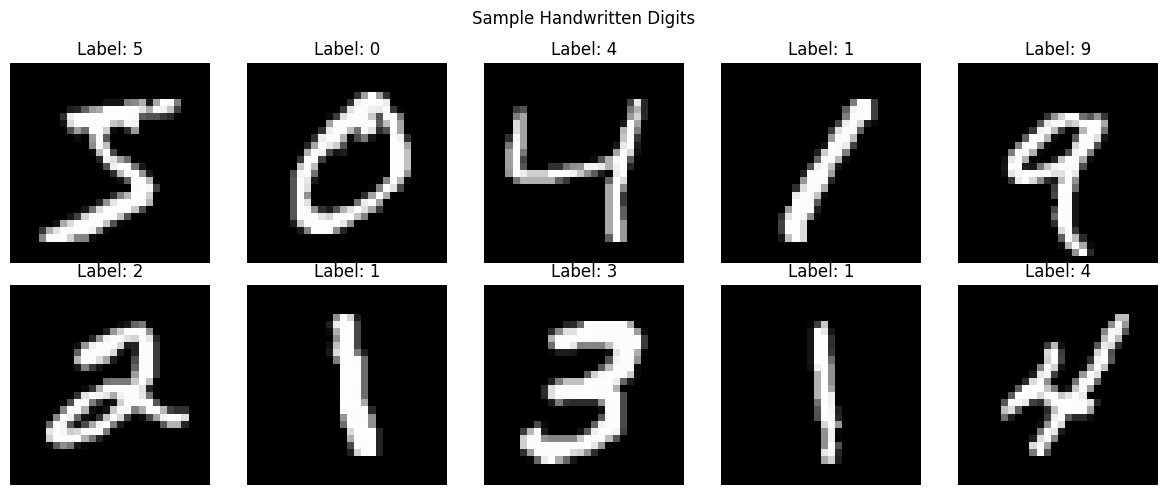

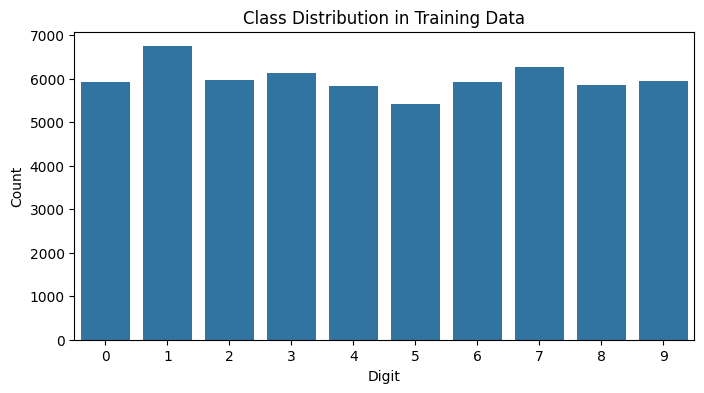

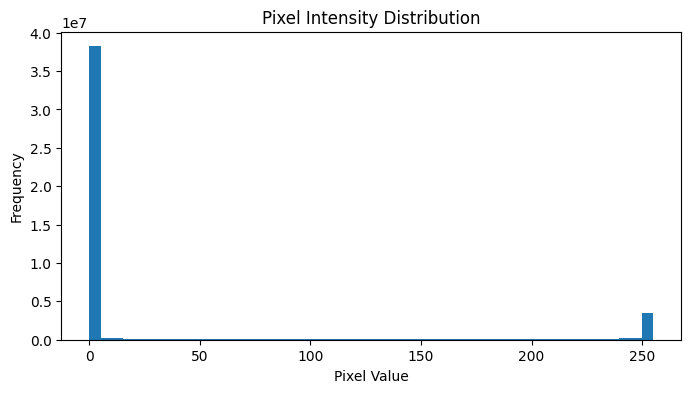

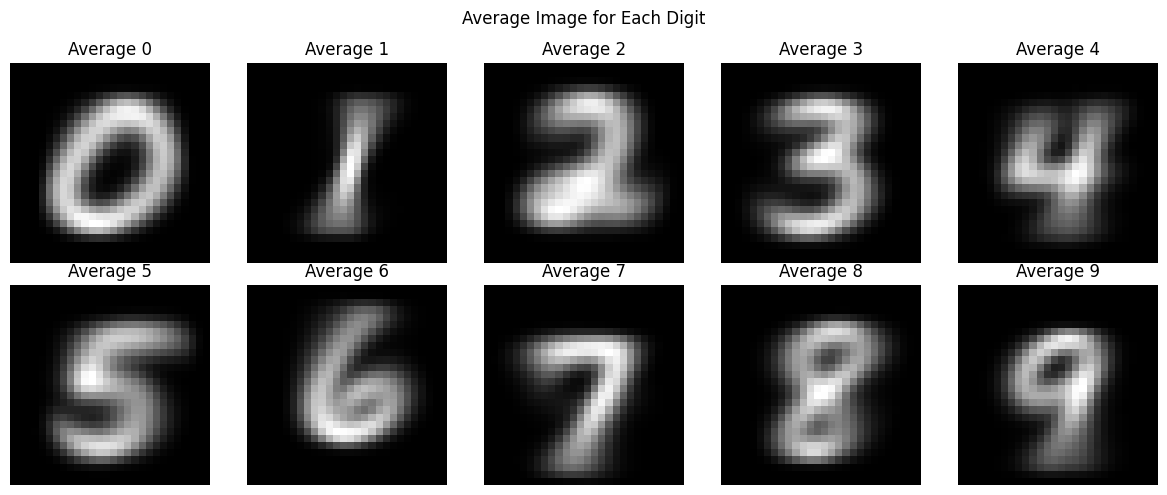

In [5]:
# Exploratory Data Analysis (EDA)

# Showing Sample Images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample Handwritten Digits")
plt.tight_layout()
plt.show()

# Class Distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution in Training Data")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

# Pixel Intensity Distribution
plt.figure(figsize=(8, 4))
plt.hist(X_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# Average Digit Images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    avg_digit = np.mean(X_train[y_train == digit], axis=0)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(avg_digit, cmap="gray")
    ax.set_title(f"Average {digit}")
    ax.axis("off")
plt.suptitle("Average Image for Each Digit")
plt.tight_layout()
plt.show()

In [6]:
# Preprocessing

# Saveing raw data for baseline flattening 
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flattened data for baseline model
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

# Reshape for CNN
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels for CNN
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("\nAfter preprocessing:")
print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape :", X_test_flat.shape)
print("X_train_cnn shape :", X_train_cnn.shape)
print("X_test_cnn shape  :", X_test_cnn.shape)



After preprocessing:
X_train_flat shape: (60000, 784)
X_test_flat shape : (10000, 784)
X_train_cnn shape : (60000, 28, 28, 1)
X_test_cnn shape  : (10000, 28, 28, 1)


In [7]:
# Logistic Regression model
start_lr = time.time()

lr_model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
lr_model.fit(X_train_flat, y_train)

end_lr = time.time()

y_pred_lr = lr_model.predict(X_test_flat)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")
print("Logistic Regression Training Time:", round(end_lr - start_lr, 2), "seconds")

/opt/anaconda3/envs/notebook/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/notebook/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/notebook/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/notebook/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3

Logistic Regression Accuracy: 92.61 %
Logistic Regression Training Time: 6.81 seconds


/opt/anaconda3/envs/notebook/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/notebook/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/notebook/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [8]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10
)

datagen.fit(X_train_cnn)

In [9]:
# CNN Model Function
def build_cnn_model(learning_rate=0.001, dropout_rate=0.3):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [10]:
# Simple Hyperparameter Search
learning_rates = [0.001, 0.0005]
batch_sizes = [64, 128]

best_val_acc = 0
best_params = None
best_model = None
best_history = None


for lr in learning_rates:
    for batch in batch_sizes:
        print(f"\nTraining model with learning_rate={lr}, batch_size={batch}")

        model = build_cnn_model(learning_rate=lr, dropout_rate=0.3)

        history = model.fit(
            datagen.flow(X_train_cnn, y_train_cat, batch_size=batch),
            validation_data=(X_test_cnn, y_test_cat),
            epochs=5,
            verbose=1
        )

        current_best_val = max(history.history['val_accuracy'])
        print("Best validation accuracy :", round(current_best_val * 100, 2), "%")

        if current_best_val > best_val_acc:
            best_val_acc = current_best_val
            best_params = {"learning_rate": lr, "batch_size": batch}
            best_model = model
            best_history = history

print("\nBest Hyperparameters:", best_params)
print("Best Validation Accuracy:", round(best_val_acc * 100, 2), "%")


Training model with learning_rate=0.001, batch_size=64
Epoch 1/5


/opt/anaconda3/envs/notebook/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8814 - loss: 0.3738 - val_accuracy: 0.9847 - val_loss: 0.0466
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9560 - loss: 0.1423 - val_accuracy: 0.9888 - val_loss: 0.0332
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9678 - loss: 0.1045 - val_accuracy: 0.9896 - val_loss: 0.0346
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9727 - loss: 0.0892 - val_accuracy: 0.9897 - val_loss: 0.0296
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9771 - loss: 0.0778 - val_accuracy: 0.9915 - val_loss: 0.0281
Best validation accuracy : 99.15 %

Training model with learning_rate=0.001, batch_size=128
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8546 - loss: 0.4566 - val_accuracy: 0.9775 - val_loss: 0.0637
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9523 - loss: 0.1600 - val_accuracy: 0.9889 - val_loss: 0.0339
Epoch 3/5
469/469 ━━━━━━━━━

In [11]:
# Final Evaluation
test_loss, test_accuracy = best_model.evaluate(X_test_cnn, y_test_cat, verbose=0)

print("CNN Test Loss:", round(test_loss, 4))
print("CNN Test Accuracy:", round(test_accuracy * 100, 2), "%")

# Predictions
y_pred_prob_cnn = best_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_prob_cnn, axis=1)

CNN Test Loss: 0.0281
CNN Test Accuracy: 99.15 %
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


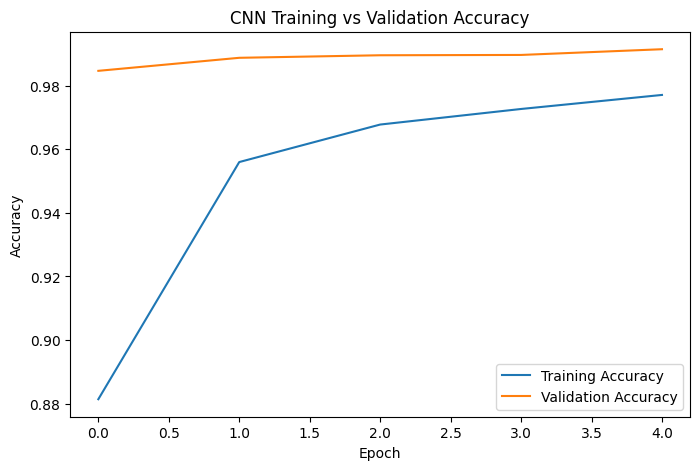

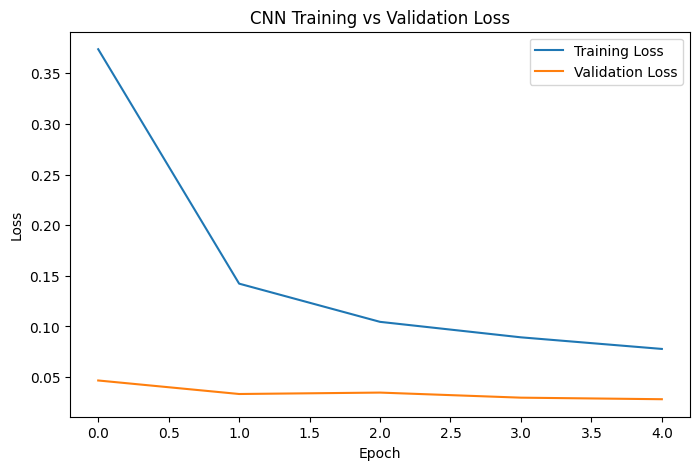

In [12]:
# Training Curves
plt.figure(figsize=(8, 5))
plt.plot(best_history.history['accuracy'], label='Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

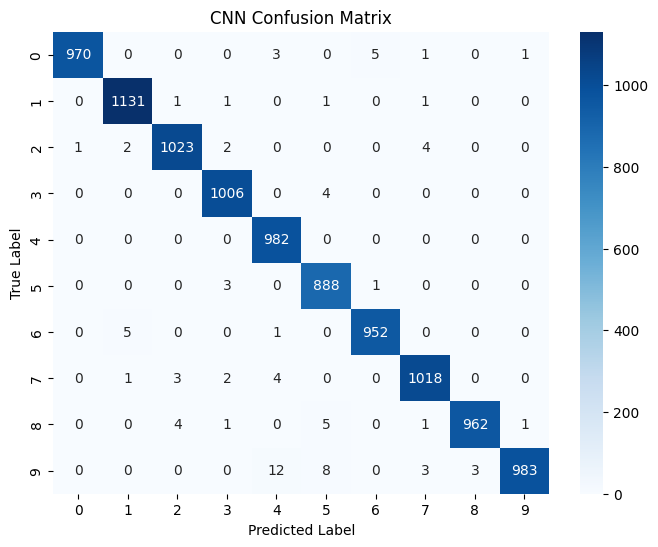

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [14]:
# Classification Report
print("\nCNN Classification Report:")
print(classification_report(y_test, y_pred_cnn))


CNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.98      1.00      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       1.00      0.97      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000




Model Comparison:
----------------------------------------
Logistic Regression Accuracy : 92.61%
CNN Accuracy                 : 99.15%


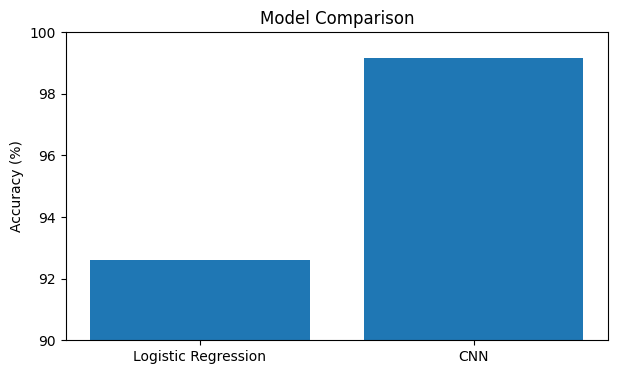

In [15]:
# Model Comparison
print("\nModel Comparison:")
print("-" * 40)
print(f"Logistic Regression Accuracy : {round(lr_accuracy * 100, 2)}%")
print(f"CNN Accuracy                 : {round(test_accuracy * 100, 2)}%")

models = ["Logistic Regression", "CNN"]
accuracies = [lr_accuracy * 100, test_accuracy * 100]

plt.figure(figsize=(7, 4))
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 100)
plt.show()

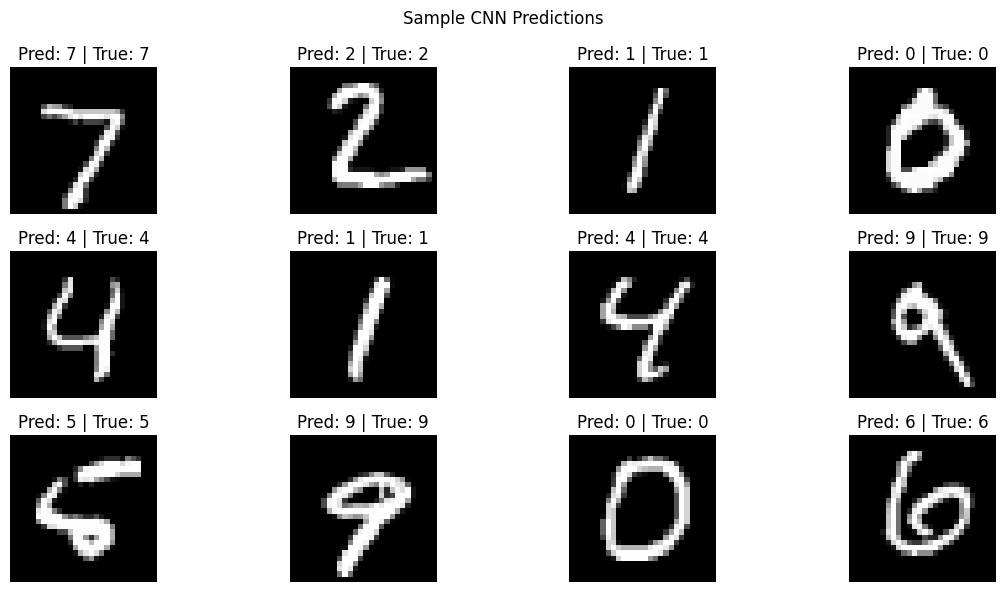

In [16]:
# Sample Predictions
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test_cnn[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {y_pred_cnn[i]} | True: {y_test[i]}")
    plt.axis("off")
plt.suptitle("Sample CNN Predictions")
plt.tight_layout()
plt.show()


Total misclassified images: 85


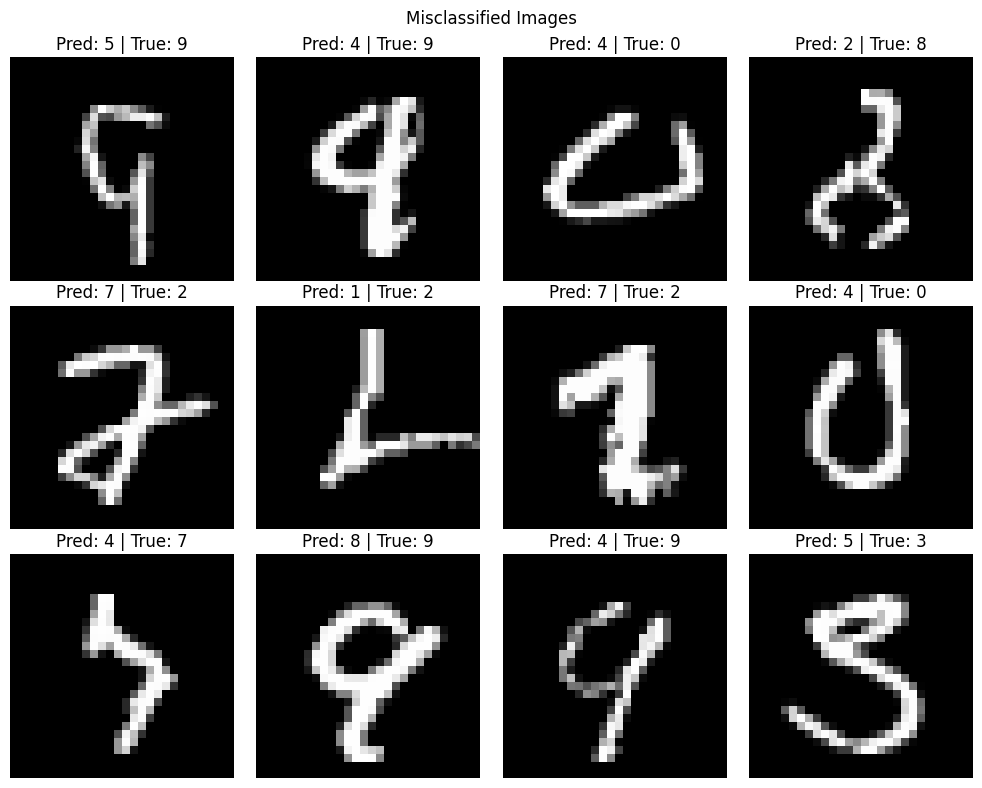


Most common misclassification pairs:
True 9 predicted as 4: 12 times
True 9 predicted as 5: 8 times
True 0 predicted as 6: 5 times
True 6 predicted as 1: 5 times
True 8 predicted as 5: 5 times
True 8 predicted as 2: 4 times
True 2 predicted as 7: 4 times
True 7 predicted as 4: 4 times
True 3 predicted as 5: 4 times
True 0 predicted as 4: 3 times


In [17]:
# Error Analysis
misclassified_indices = np.where(y_pred_cnn != y_test)[0]

print("\nTotal misclassified images:", len(misclassified_indices))

plt.figure(figsize=(10, 8))
for i, idx in enumerate(misclassified_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test_cnn[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {y_pred_cnn[idx]} | True: {y_test[idx]}")
    plt.axis("off")
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()

# most common confusion pairs
confusion_pairs = []
for idx in misclassified_indices:
    confusion_pairs.append((y_test[idx], y_pred_cnn[idx]))

from collections import Counter
pair_counts = Counter(confusion_pairs)

print("\nMost common misclassification pairs:")
for pair, count in pair_counts.most_common(10):
    print(f"True {pair[0]} predicted as {pair[1]}: {count} times")

In [18]:
# Save Model
best_model.save("models/mnist_cnn_best_model.h5")
print("\nBest CNN model saved as models/mnist_cnn_best_model.h5")


Best CNN model saved as models/mnist_cnn_best_model.h5
